In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

# Load từ Drive (đổi path nếu bạn lưu chỗ khác)
DRIVE_FOLDER = '/content/drive/MyDrive/Cloud_dataset/'

df = pd.read_csv(DRIVE_FOLDER + 'data_clean.csv')

with open(DRIVE_FOLDER + 'feature_config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
TARGET_COL   = config['target_col']

print(f"Shape: {df.shape}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Shape: (4499, 15)
Features (11): ['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'house_age', 'was_renovated']


In [ ]:
from sklearn.model_selection import train_test_split

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values   # đây là log(price)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 3599 rows
Test:  900 rows


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

pipelines = {
    'LinearRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),

    'RandomForest': Pipeline([
        # RF không cần scaler nhưng bọc vào pipeline cho nhất quán
        ('scaler', StandardScaler()),
        ('model',  RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            min_samples_leaf=5,
            n_jobs=-1,
            random_state=42
        ))
    ]),

    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            max_iter=500,
            early_stopping=True,    # tránh overfit
            validation_fraction=0.1,
            random_state=42
        ))
    ])
}

print("Đã định nghĩa 3 pipelines ✓")
for name in pipelines:
    print(f"  - {name}")

Đã định nghĩa 3 pipelines ✓
  - LinearRegression
  - RandomForest
  - MLP


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

for name, pipeline in pipelines.items():
    print(f"Training {name}...", end=' ')

    # Train
    pipeline.fit(X_train, y_train)

    # Predict trên test set — ra log(price)
    y_pred_log = pipeline.predict(X_test)

    # Đổi ngược về USD để tính metrics thực tế
    y_pred_usd = np.exp(y_pred_log)
    y_test_usd = np.exp(y_test)

    # Tính metrics
    mae  = mean_absolute_error(y_test_usd, y_pred_usd)
    rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
    r2   = r2_score(y_test, y_pred_log)   # R² tính trên log scale

    # Tính MAPE (mean absolute percentage error)
    mape = np.mean(np.abs((y_test_usd - y_pred_usd) / y_test_usd)) * 100

    results[name] = {
        'pipeline': pipeline,
        'y_pred_log': y_pred_log,
        'y_pred_usd': y_pred_usd,
        'MAE':  mae,
        'RMSE': rmse,
        'R2':   r2,
        'MAPE': mape
    }

    print(f"xong ✓  |  MAE=${mae:>8,.0f}  RMSE=${rmse:>8,.0f}  "
          f"R²={r2:.4f}  MAPE={mape:.1f}%")

Training LinearRegression... xong ✓  |  MAE=$ 145,024  RMSE=$ 206,481  R²=0.5162  MAPE=30.2%
Training RandomForest... xong ✓  |  MAE=$ 138,646  RMSE=$ 189,647  R²=0.5268  MAPE=29.8%
Training MLP... xong ✓  |  MAE=$ 162,932  RMSE=$ 291,562  R²=0.4248  MAPE=33.1%


In [ ]:
# Bảng so sánh
summary = pd.DataFrame({
    name: {
        'MAE ($)':   f"${r['MAE']:>10,.0f}",
        'RMSE ($)':  f"${r['RMSE']:>10,.0f}",
        'R²':        f"{r['R2']:.4f}",
        'MAPE (%)':  f"{r['MAPE']:.2f}%"
    }
    for name, r in results.items()
}).T

print("=== BẢNG SO SÁNH MODEL ===")
print(summary.to_string())

=== BẢNG SO SÁNH MODEL ===
                      MAE ($)     RMSE ($)      R² MAPE (%)
LinearRegression  $   145,024  $   206,481  0.5162   30.22%
RandomForest      $   138,646  $   189,647  0.5268   29.78%
MLP               $   162,932  $   291,562  0.4248   33.12%


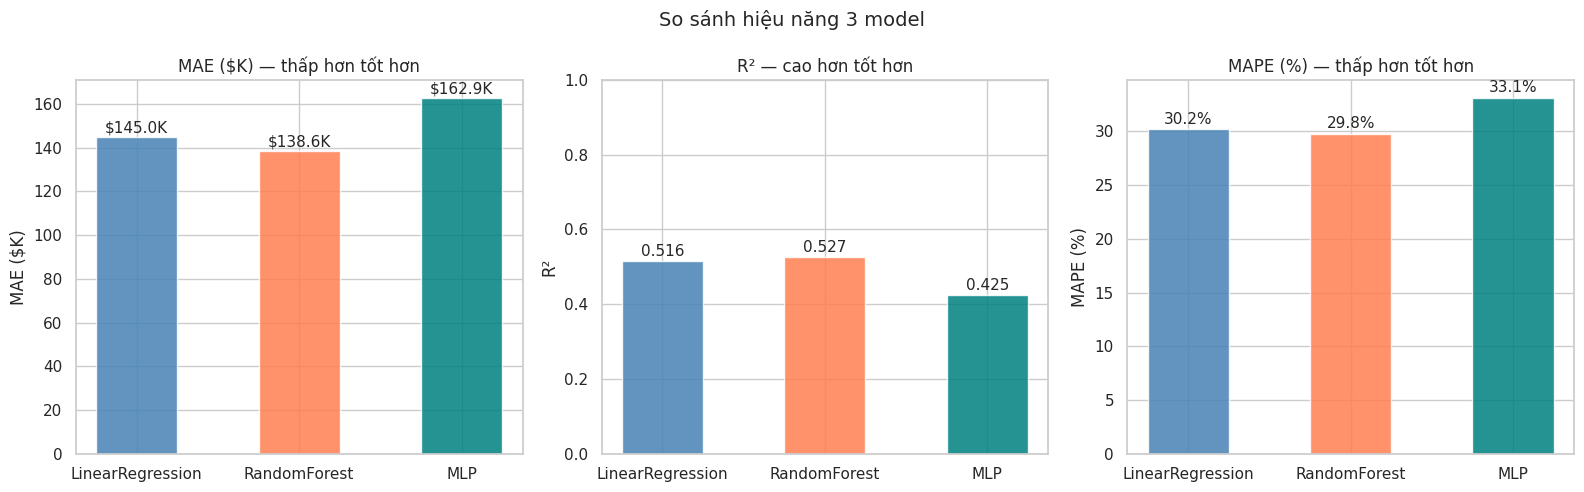

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names   = list(results.keys())
colors  = ['steelblue', 'coral', 'teal']
maes    = [results[n]['MAE']  / 1000 for n in names]
rmses   = [results[n]['RMSE'] / 1000 for n in names]
r2s     = [results[n]['R2']          for n in names]
mapes   = [results[n]['MAPE']        for n in names]

# MAE
bars = axes[0].bar(names, maes, color=colors, alpha=0.85, width=0.5)
axes[0].set_title('MAE ($K) — thấp hơn tốt hơn')
axes[0].set_ylabel('MAE ($K)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'${val:.1f}K', ha='center', va='bottom', fontsize=11)

# R²
bars = axes[1].bar(names, r2s, color=colors, alpha=0.85, width=0.5)
axes[1].set_title('R² — cao hơn tốt hơn')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)

# MAPE
bars = axes[2].bar(names, mapes, color=colors, alpha=0.85, width=0.5)
axes[2].set_title('MAPE (%) — thấp hơn tốt hơn')
axes[2].set_ylabel('MAPE (%)')
for bar, val in zip(bars, mapes):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.suptitle('So sánh hiệu năng 3 model', fontsize=14)
plt.tight_layout()
plt.show()

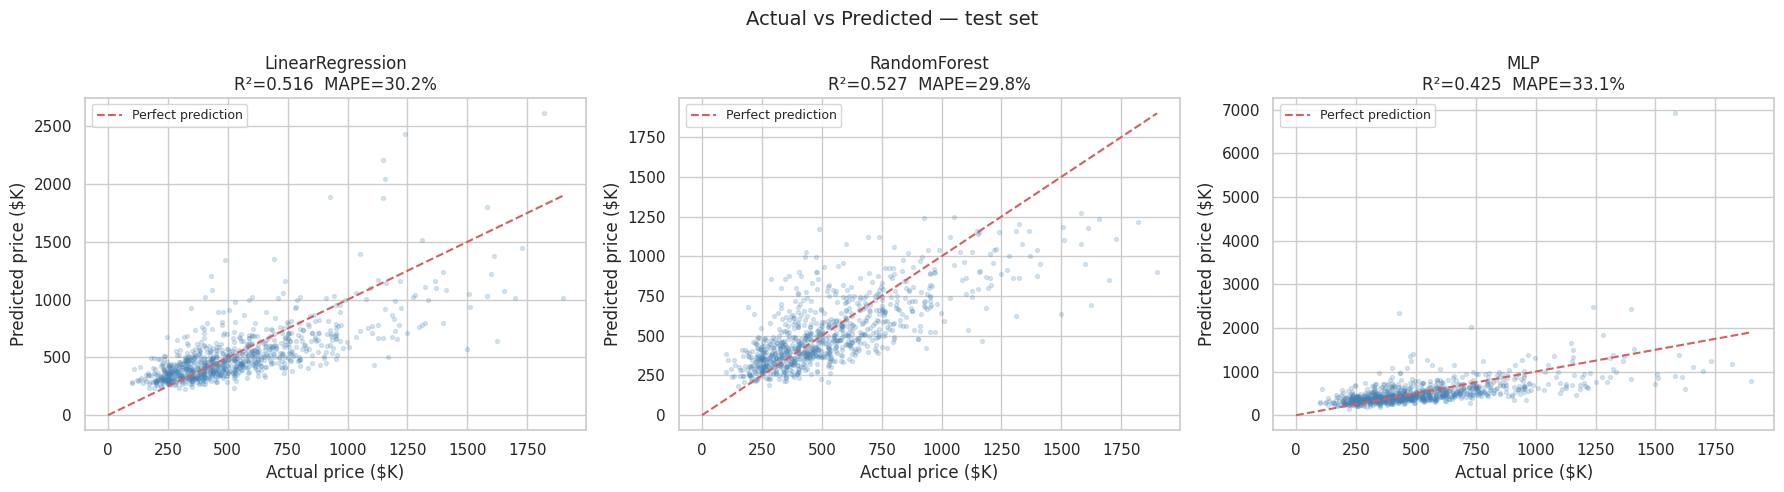

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

y_test_usd = np.exp(y_test)
max_val = y_test_usd.max()

for ax, (name, r) in zip(axes, results.items()):
    ax.scatter(y_test_usd / 1000, r['y_pred_usd'] / 1000,
               alpha=0.2, s=8, color='steelblue')

    # Đường perfect prediction
    ax.plot([0, max_val/1000], [0, max_val/1000],
            'r--', linewidth=1.5, label='Perfect prediction')

    ax.set_title(f'{name}\nR²={r["R2"]:.3f}  MAPE={r["MAPE"]:.1f}%')
    ax.set_xlabel('Actual price ($K)')
    ax.set_ylabel('Predicted price ($K)')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — test set', fontsize=14)
plt.tight_layout()
plt.show()

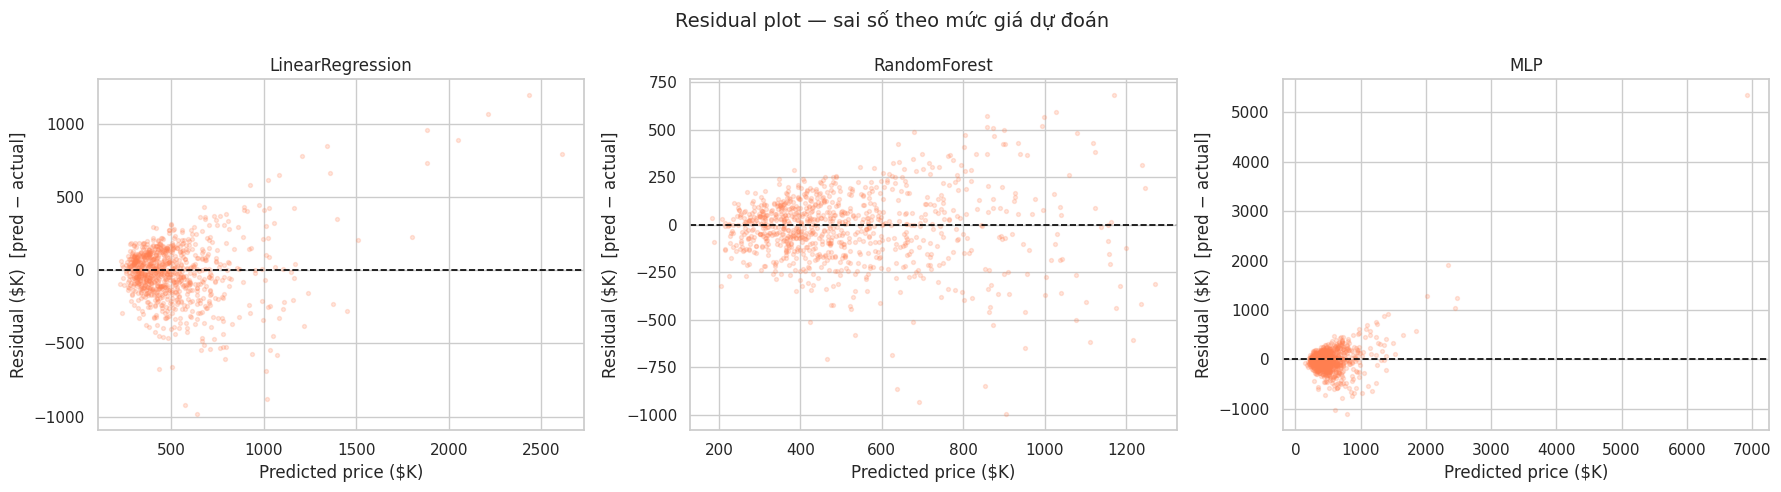

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, r) in zip(axes, results.items()):
    y_test_usd = np.exp(y_test)
    residuals  = r['y_pred_usd'] - y_test_usd   # sai số (USD)

    ax.scatter(r['y_pred_usd'] / 1000, residuals / 1000,
               alpha=0.2, s=8, color='coral')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted price ($K)')
    ax.set_ylabel('Residual ($K)  [pred − actual]')

plt.suptitle('Residual plot — sai số theo mức giá dự đoán', fontsize=14)
plt.tight_layout()
plt.show()

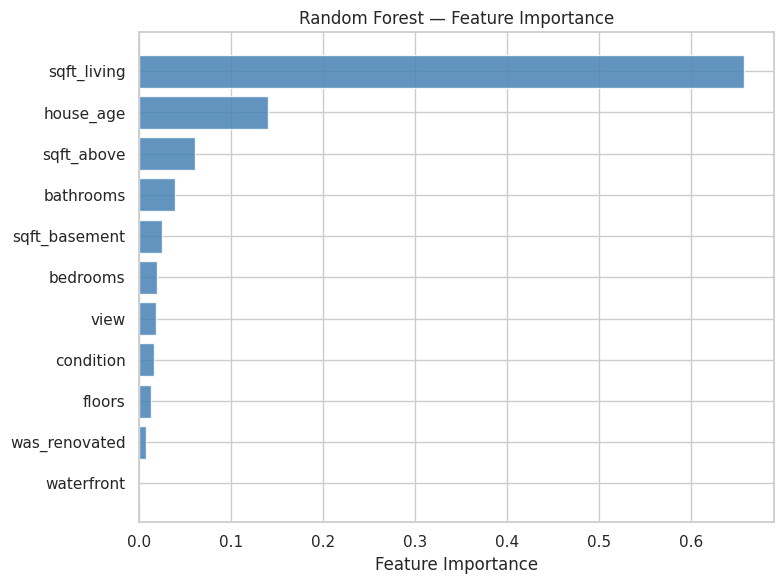

Top features:
      feature  importance
  sqft_living    0.657249
    house_age    0.140743
   sqft_above    0.060758
    bathrooms    0.039674
sqft_basement    0.025340
     bedrooms    0.019624
         view    0.018848
    condition    0.017002
       floors    0.012996
was_renovated    0.007768
   waterfront    0.000000


In [ ]:
rf_model = results['RandomForest']['pipeline'].named_steps['model']

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='steelblue', alpha=0.85)
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

print("Top features:")
print(importance_df.sort_values('importance', ascending=False)
      .to_string(index=False))

In [ ]:
MODEL_FOLDER = '/content/drive/MyDrive/house-price-prediction/model/'

import os
os.makedirs(MODEL_FOLDER, exist_ok=True)

export_map = {
    'LinearRegression': 'lr_pipeline.joblib',
    'RandomForest':     'rf_pipeline.joblib',
    'MLP':              'mlp_pipeline.joblib'
}

for name, filename in export_map.items():
    path = MODEL_FOLDER + filename
    joblib.dump(results[name]['pipeline'], path)
    size_kb = os.path.getsize(path) / 1024
    print(f"✓ {filename:30s} ({size_kb:.1f} KB)")

# Copy stats.json và feature_config.json vào model folder luôn
import shutil
shutil.copy(DRIVE_FOLDER + 'stats.json',
            MODEL_FOLDER + 'stats.json')
shutil.copy(DRIVE_FOLDER + 'feature_config.json',
            MODEL_FOLDER + 'feature_config.json')

print(f"\nTất cả file đã lưu tại: {MODEL_FOLDER}")
print("\n=== BÀN GIAO CHO MEMBER B ===")
print(f"  lr_pipeline.joblib")
print(f"  rf_pipeline.joblib")
print(f"  mlp_pipeline.joblib")
print(f"  stats.json")
print(f"  feature_config.json")

✓ lr_pipeline.joblib             (1.4 KB)
✓ rf_pipeline.joblib             (4777.7 KB)
✓ mlp_pipeline.joblib            (242.3 KB)

Tất cả file đã lưu tại: /content/drive/MyDrive/house-price-prediction/model/

=== BÀN GIAO CHO MEMBER B ===
  lr_pipeline.joblib
  rf_pipeline.joblib
  mlp_pipeline.joblib
  stats.json
  feature_config.json


In [ ]:
print("=== KIỂM TRA FILE ĐÃ EXPORT ===\n")

for name, filename in export_map.items():
    path = MODEL_FOLDER + filename

    # Load lại và predict thử
    loaded = joblib.load(path)
    test_input = X_test[:1]
    pred_log   = loaded.predict(test_input)[0]
    pred_usd   = np.exp(pred_log)
    actual_usd = np.exp(y_test[0])

    print(f"{name}")
    print(f"  Predicted: ${pred_usd:>10,.0f}")
    print(f"  Actual:    ${actual_usd:>10,.0f}")
    print(f"  Error:     ${abs(pred_usd - actual_usd):>10,.0f}\n")

print("→ Tất cả model load và predict được ✓")
print("→ Sẵn sàng bàn giao cho Member B để tích hợp vào FastAPI")

=== KIỂM TRA FILE ĐÃ EXPORT ===

LinearRegression
  Predicted: $   557,831
  Actual:    $   825,500
  Error:     $   267,669

RandomForest
  Predicted: $   565,908
  Actual:    $   825,500
  Error:     $   259,592

MLP
  Predicted: $   518,886
  Actual:    $   825,500
  Error:     $   306,614

→ Tất cả model load và predict được ✓
→ Sẵn sàng bàn giao cho Member B để tích hợp vào FastAPI


In [ ]:
import sklearn, numpy
print(f"sklearn: {sklearn.__version__}")
print(f"numpy:   {numpy.__version__}")

sklearn: 1.6.1
numpy:   2.0.2
